### Importação de bibliotecas

In [1]:
pip show monai || pip install "monai[all]"

Name: monai
Version: 1.4.0
Summary: AI Toolkit for Healthcare Imaging
Home-page: https://monai.io/
Author: MONAI Consortium
Author-email: monai.contact@gmail.com
License: Apache License 2.0
Location: /home/labian-2/Desktop/Crateus/odonto_forense/.venv/lib/python3.12/site-packages
Requires: numpy, torch
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip show tensorboard || pip install tensorboard

Name: tensorboard
Version: 2.19.0
Summary: TensorBoard lets you watch Tensors Flow
Home-page: https://github.com/tensorflow/tensorboard
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /home/labian-2/Desktop/Crateus/odonto_forense/.venv/lib/python3.12/site-packages
Requires: absl-py, grpcio, markdown, numpy, packaging, protobuf, setuptools, six, tensorboard-data-server, werkzeug
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip show timm_3d || pip install timm_3d

Name: timm-3d
Version: 1.0.1
Summary: Python library with Neural Networks for Volume (3D) Classification based on PyTorch.
Home-page: https://github.com/ZFTurbo/timm_3d
Author: Roman Sol (ZFTurbo)
Author-email: UNKNOWN
License: UNKNOWN
Location: /home/labian-2/Desktop/Crateus/odonto_forense/.venv/lib/python3.12/site-packages
Requires: huggingface-hub, pyyaml, safetensors, torch, torchvision
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip show wandb || pip install wandb 

Name: wandb
Version: 0.20.1
Summary: A CLI and library for interacting with the Weights & Biases API.
Home-page: 
Author: 
Author-email: Weights & Biases <support@wandb.com>
License: MIT License

Copyright (c) 2021 Weights and Biases, Inc.

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEM

In [5]:
import glob
import os

import monai
from monai.transforms import LoadImage
from monai.data import DataLoader, Dataset
from monai.data.image_reader import NibabelReader
from monai.data import MetaTensor #Corte
from monai.data import pad_list_data_collate
from monai.utils import first
from monai.transforms import (
    EnsureChannelFirst,
    Compose,
    RandFlip,
    RandRotate,
    RandZoom,
    RandAffine,
    ToTensor,
    ToNumpy,
    SpatialPad
)

import torch
from torch import Tensor
import torch.nn.functional as F
from typing import Tuple
from torchmetrics.classification import BinaryAccuracy

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from torchmetrics.classification import BinaryAccuracy
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import numpy as np

import warnings
warnings.filterwarnings('ignore')

from dataclasses import dataclass

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


### Parâmetros

In [11]:
@dataclass(frozen=True)
class DatasetConfig:
    INTERPOLATE_MODE: str = 'nearest'
    INTERPOLATE_SIZE: int = (128,256, 256)
    PARA_DATA: bool = True
    BAHIA_DATA: bool = True
    CEARA_DATA: bool = True
    BINARY_DATA: bool = False
    ALL_SINUSES: bool = True
    ONLY_FRONTAL: bool = False
    ONLY_MAXILLARY: bool = False
    ONLY_SPHENOIDAL: bool = False

@dataclass(frozen=True)
class TrainingConfig:    
    BATCH_SIZE_TRAINING: int = 2
    BATCH_SIZE_VAL: int = 2
    BATCH_SIZE_TEST: int = 2
    NUM_WORKERS: int = 3
    NUM_EPOCHS: int = 1000
    LEARNING_RATE: float = 0.001
    DATA_AUGMENTATION: bool = True
    UNFREEZE_LAYERS: bool = True
    TEST_SIZE: float = 0.2
    VAL_SIZE: float = 0.1
    NUM_FOLDS: int = 3

### Diretórios

In [12]:
# Definir os caminhos das pastas dentro do Google Drive
# Pará
base_dir_homens_para = 'Imagens_Engine/Pará/Máscaras/Homens' 
base_dir_mulheres_para = 'Imagens_Engine/Pará/Máscaras/Mulheres'

# Ceará
base_dir_homens_ceara = 'Imagens_Engine/Ceará/Máscaras/Homens' 
base_dir_mulheres_ceara = 'Imagens_Engine/Ceará/Máscaras/Mulheres'

# Bahia
base_dir_homens_bahia = 'Imagens_Engine/Bahia/Máscaras/Homens' 
base_dir_mulheres_bahia = 'Imagens_Engine/Bahia/Máscaras/Mulheres'

# Buscar arquivos de homens e mulheres para cada estado
# Pará
arquivos_homens_para = glob.glob(os.path.join(base_dir_homens_para, '**', '*.*'), recursive=True)[:-1]
arquivos_mulheres_para = glob.glob(os.path.join(base_dir_mulheres_para, '**', '*.*'), recursive=True)

# Ceará
arquivos_homens_ceara = glob.glob(os.path.join(base_dir_homens_ceara, '**', '*.*'), recursive=True)
arquivos_mulheres_ceara = glob.glob(os.path.join(base_dir_mulheres_ceara, '**', '*.*'), recursive=True)[:8]

# Bahia
arquivos_homens_bahia = glob.glob(os.path.join(base_dir_homens_bahia, '**', '*.*'), recursive=True)
arquivos_mulheres_bahia = glob.glob(os.path.join(base_dir_mulheres_bahia, '**', '*.*'), recursive=True)[:12]

# Todos os estados
arquivos_homens = []
arquivos_mulheres = []

if DatasetConfig.PARA_DATA:
    arquivos_homens += arquivos_homens_para
    arquivos_mulheres += arquivos_mulheres_para
if DatasetConfig.CEARA_DATA:
    arquivos_homens += arquivos_homens_ceara
    arquivos_mulheres += arquivos_mulheres_ceara
if DatasetConfig.BAHIA_DATA:
    arquivos_homens += arquivos_homens_bahia
    arquivos_mulheres += arquivos_mulheres_bahia

# 4. Exibir a quantidade de arquivos encontrados para cada estado
print("=== Arquivos no estado do Pará ===")
print(f"Seios paranasais masculinos: {len(arquivos_homens_para)}")
print(f"Seios paranasais femininos: {len(arquivos_mulheres_para)}")

print("\n=== Arquivos no estado do Ceará ===")
print(f"Seios paranasais masculinos: {len(arquivos_homens_ceara)}")
print(f"Seios paranasais femininos: {len(arquivos_mulheres_ceara)}")

print("\n=== Arquivos no estado da Bahia ===")
print(f"Seios paranasais masculinos: {len(arquivos_homens_bahia)}")
print(f"Seios paranasais femininos: {len(arquivos_mulheres_bahia)}")

print("\n=== Total geral de arquivos ===")
print(f"Total de seios paranasais masculinos: {len(arquivos_homens)}")
print(f"Total de seios paranasais femininos: {len(arquivos_mulheres)}")


=== Arquivos no estado do Pará ===
Seios paranasais masculinos: 34
Seios paranasais femininos: 34

=== Arquivos no estado do Ceará ===
Seios paranasais masculinos: 8
Seios paranasais femininos: 8

=== Arquivos no estado da Bahia ===
Seios paranasais masculinos: 12
Seios paranasais femininos: 12

=== Total geral de arquivos ===
Total de seios paranasais masculinos: 54
Total de seios paranasais femininos: 54


### Funções

1. Carregar volume

In [13]:
wrong_color1 = [
    "1-1333663.nii",
    "2-1335860.nii",
    "5-1403689.nii",
    "7-1428546.nii",
    "11-1471830.nii",
    "13-1496874.nii",
    "15-1507438.nii",
    "16-1508238.nii",
    "17-1509330.nii",
    "18-1667248.nii",
    "19-1674535.nii",
    "20-1691088.nii",
    "21-1352496.nii",
    "22-1384117.nii",
    "23-1461794.nii",
    "25-1515477.nii",
    "26-1545421.nii",
    "27-1546288.nii",
    "28-1574248.nii",
    "31-1668313.nii",
    "32-1675835.nii",
    "33-1676414.nii",
    "34-1276334.nii",
    "38-1247673.nii",
    "39-1347053.nii",
    "40-1456571.nii"
]

wrong_color2 = [
    "103-1404890.nii",
    "106-1463342.nii",
    "303.nii",
    "305.nii",
    "306.nii",
    "321.nii",
    "322.nii",
    "341.nii",
    "342.nii"
]


In [14]:
def load_volume(path: str):
    loader = LoadImage(image_only=True) 
    volume = loader(path)

    if 6.0 in volume.unique():
        volume_orig = volume.clone()
        volume = torch.where(volume_orig == 5.0, torch.tensor(4.0), volume)
        volume = torch.where(volume_orig == 6.0, torch.tensor(5.0), volume)

    if DatasetConfig.BINARY_DATA:
        if DatasetConfig.ALL_SINUSES:
            volume[volume > 0] = 1

        elif DatasetConfig.ONLY_FRONTAL:
            volume = torch.where(volume == 2.0, torch.tensor(1.0), torch.tensor(0.0))

        elif DatasetConfig.ONLY_SPHENOIDAL:
            volume = torch.where(volume == 3.0, torch.tensor(1.0), torch.tensor(0.0))

        elif DatasetConfig.ONLY_MAXILLARY:
            volume = torch.where((volume == 4.0) | (volume == 5.0), torch.tensor(1.0), torch.tensor(0.0))

        return volume.as_tensor()
    else:
        filename = os.path.basename(path)
        volume_orig = volume.clone()

        if filename in wrong_color1:
            volume = torch.where(volume_orig == 5.0, torch.tensor(2.0), volume)
            volume = torch.where(volume_orig == 4.0, torch.tensor(3.0), volume)
            volume = torch.where(volume_orig == 2.0, torch.tensor(4.0), volume)
            volume = torch.where(volume_orig == 3.0, torch.tensor(5.0), volume)
        elif filename in wrong_color2:
            volume = torch.where(volume_orig == 4.0, torch.tensor(5.0), volume)
            volume = torch.where(volume_orig == 3.0, torch.tensor(4.0), volume)
            volume = torch.where(volume_orig == 5.0, torch.tensor(3.0), volume)

    print(f"-------- Carregamento do volume --------") 
    print(f"Tipo de dado do tensor: {volume.dtype}")                  # torch.float32
    print(f"Tamanho do tensor: {volume.shape}")                       # torch.Size([512, 512, 245]) -> (H,W,D)                  
    print(f"Dados presentes no tensor: {volume.unique()}")            # tensor([0., 2., 3., 4., 5.])
    # print(volume.meta)                                                # mostra os metadados da imagem

    return volume.as_tensor()

2. Interpolação

In [15]:
def interpolate_volume(volume: Tensor, vol_size=DatasetConfig.INTERPOLATE_SIZE):
    vol_shape = tuple(volume.shape) # (H,W,D)

    if vol_shape == vol_size:
        return volume
    
    max_dim = max(vol_shape)
    volume = SpatialPad(spatial_size=(max_dim,max_dim,max_dim))(volume.unsqueeze(dim=0)).squeeze(dim=0)
    
    # Troca as posições das dimensões para (D,H,W)
    volume = volume.permute(2,0,1)
    # Adiciona duas dimensões no início para que o .shape seja (Batch,Channel,Depth,Height,Width)
    volume = volume.unsqueeze(0).unsqueeze(0)

    # O interpolate recebe o tensor no formato: mini-batch x channels x [optional depth] x [optional height] x width.
    interpolated = F.interpolate(volume, size=vol_size, mode = DatasetConfig.INTERPOLATE_MODE)[0,0]

    # Retorna um tensor com .shape (D,H,W)
    return interpolated  #passar a tupla retorno a tupla (tensor, shape antigo)

3. Corte

In [16]:
def crop_volume(volume: Tensor, valor_minimo= 0.0) -> Tensor:
    # Função auxiliar para encontrar o primeiro slice com valor acima do valor_minimo
    def primeiro_slice(volume, eixo):
        for i in range(volume.shape[eixo]):
            if eixo == 0 and torch.any(volume[i, :, :]) != valor_minimo:
                return i
            elif eixo == 1 and torch.any(volume[:, i, :]) != valor_minimo:
                return i
            elif eixo == 2 and torch.any(volume[:, :, i]) != valor_minimo:
                return i
        return None

    # Função auxiliar para encontrar o último slice com valor acima do valor_minimo
    def ultimo_slice(volume, eixo):
        for i in range(volume.shape[eixo] - 1, -1, -1):
            if eixo == 0 and torch.any(volume[i, :, :]) != valor_minimo:
                return i
            elif eixo == 1 and torch.any(volume[:, i, :]) != valor_minimo:
                return i
            elif eixo == 2 and torch.any(volume[:, :, i]) != valor_minimo:
                return i
        return None

    # Encontrando os slices para cada eixo
    x_primeiro_slice = primeiro_slice(volume, 0)
    x_ultimo_slice = ultimo_slice(volume, 0)
    y_primeiro_slice = primeiro_slice(volume, 1)
    y_ultimo_slice = ultimo_slice(volume, 1)
    z_primeiro_slice = primeiro_slice(volume, 2)
    z_ultimo_slice = ultimo_slice(volume, 2)

    if None in [x_primeiro_slice, x_ultimo_slice, y_primeiro_slice, y_ultimo_slice, z_primeiro_slice, z_ultimo_slice]:
        raise ValueError("Não foram encontrados slices com valores acima do valor mínimo especificado.")

    # Cortando o MetaTensor mantendo os metadados
    volume_cortado = volume[
        x_primeiro_slice-8:x_ultimo_slice + 12, # coloquei +8 e -8 pra deixar 8 slices de margem pro corte, pois antes estava recortando o seios paranasal
        y_primeiro_slice-8:y_ultimo_slice + 12,
        z_primeiro_slice-8:z_ultimo_slice + 12
    ]

    return volume_cortado

### Mostrar volume

In [17]:
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

1. Mostra o volume 3D -> recebe um tensor

In [18]:
def plot_volume(volume, threshold=0.01, colored=True, save=False, folder=None, title=None):
    """
    Plota um volume 3D com cor única ou múltiplas cores dependendo do valor de `colored`.
    
    Args:
        volume (torch.Tensor): Tensor 3D no formato (H, W, D).
        threshold (float): Threshold para o marching cubes.
        colored (bool): Se True, usa cores diferentes para cada valor distinto no volume.
        save (bool): Se True, salva a imagem na pasta folder.
        folder (str): Caminho onde a imagem será salva.
        title (str): Nome do arquivo.
    """
    
    if volume.dim() == 4:
        volume = volume.squeeze(0)

    volume_np = volume.cpu().numpy()
    volume_np = volume_np.transpose(0, 1, 2)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    if colored:
        unique_values = np.unique(volume_np)
        unique_values = unique_values[unique_values != 0]

        color_map = {
            2.0: "#00008B",   # Azul escuro – Seio frontal - 100
            3.0: "#00FFFF",  # Ciano – Seio esfenoidal - 300
            4.0: "#FFFF00",  # Amarelo – Seio maxilar - 200
            5.0: "#8B0000",  # Vermelho escuro – Seio etmoidal - 100
        }

        for value in unique_values:
            if value in color_map:
                verts, faces, _, _ = measure.marching_cubes(volume_np == value, level=0.5)
                mesh = Poly3DCollection(verts[faces], alpha=0.7)
                mesh.set_facecolor(color_map[value])
                ax.add_collection3d(mesh)

    else:
        verts, faces, _, _ = measure.marching_cubes(volume_np, level=threshold)
        mesh = Poly3DCollection(verts[faces], alpha=1.0)
        mesh.set_facecolor("#00008B")  # Azul padrão
        ax.add_collection3d(mesh)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=20, azim=10)

    if save and title and folder:
        os.makedirs(folder, exist_ok=True)
        path = os.path.splitext(os.path.basename(title))[0]
        file_name = os.path.join(folder, f"{path}.png")
        plt.savefig(file_name, dpi=300)
        plt.close()
    else:
        plt.show()

2. Plota as fatias 2D

In [19]:
def plot_slices(first_slice, num_rows, num_columns, width, height, data):
    """
    Exibe uma montagem de fatias de uma imagem 3D em um grid.

    Args:
        data (torch.Tensor): Volume 3D no formato (D, H, W), onde D é o número de fatias.
        first_slice (int): Índice da primeira fatia a ser exibida.
        num_rows (int): Número de linhas no grid de fatias.
        num_columns (int): Número de colunas no grid de fatias.
        height (int): Altura de cada fatia.
        width (int): Largura de cada fatia.
    """
    data = data.cpu().numpy()

    # Transpor o volume para que ele seja plotado na orientação correta (eixos Z, Y, X)
    data= data.transpose(0, 1, 2)

    # Selecionar as fatias necessárias
    total_slices = num_rows * num_columns
    slices = data[first_slice:first_slice + total_slices, :, :]  # Seleciona as fatias para o grid

    # Reformatar os dados para se ajustar ao grid de fatias
    slices = np.reshape(slices, (num_rows, num_columns, height, width))

    # Criar a figura com a montagem
    fig_width = 12.0
    fig_height = fig_width * num_rows / num_columns
    f, axarr = plt.subplots(num_rows, num_columns, figsize=(fig_width, fig_height))

    for i in range(num_rows):
        for j in range(num_columns):
            axarr[i, j].imshow(slices[i, j], cmap="gray")
            axarr[i, j].axis("off")

    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    plt.show()

3. Salva e/ou mostra a representação do volume: Normal, com Corte e com Corte + Interpolação.

In [20]:
def show_processed_volumes_3(volume, folder_path=None, save=False, threshold=0.01):
    file_name = volume
    v1 = load_volume(volume)
    v2 = crop_volume(v1)
    v3 = interpolate_volume(v2).permute(1,2,0)
    
    fig = plt.figure(figsize=(18, 6))  # Tamanho maior para caber os 3 gráficos

    for i, (volume, titulo) in enumerate(zip([v1,v2,v3], ["Normal", "Corte", "Corte + Interpolação"])):
        if volume.dim() == 4:
            volume = volume.squeeze(0)

        volume_np = volume.cpu().numpy()

        unique_values = np.unique(volume_np)
        unique_values = unique_values[unique_values != 0]

        color_map = {
            100.0: "#00008B",  # Azul escuro
            -300.0: "#00FFFF",  # Ciano
            -200.0: "#FFFF00",  # Amarelo
            -100.0: "#8B0000",  # Vermelho escuro
        }

        ax = fig.add_subplot(1, 3, i + 1, projection='3d')

        for value in unique_values:
            if value in color_map:
                color = color_map[value]
                verts, faces, _, _ = measure.marching_cubes(volume_np == value, threshold)
                mesh = Poly3DCollection(verts[faces], alpha=0.7)
                mesh.set_facecolor(color)
                ax.add_collection3d(mesh)


        # Fixar limites para consistência
        ax.set_xlim(0, 256)
        ax.set_ylim(0, 256)
        ax.set_zlim(0, 128)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(titulo)
        ax.view_init(elev=80, azim=30)

    if save and file_name and folder_path:
        os.makedirs(folder_path, exist_ok=True)
        path = os.path.splitext(os.path.basename(file_name))[0]
        file_name = os.path.join(folder_path, f"{path}.png")
        plt.savefig(file_name, dpi=300)
        plt.close()
    else:
        plt.tight_layout()
        plt.show()

4. Salva e/ou mostra a representação do volume: Normal e com Corte

In [21]:
def show_processed_volumes_2(volume, folder_path=None, save=False, threshold=0.01):
    file_name = volume

    v1 = load_volume(volume)
    print(f"Forma e tipo do volume: {v1.shape} >> {v1.dtype}")
 
    v2 = crop_volume(v1)
    print(f"Forma e tipo do volume cortado: {v2.shape} >> {v2.dtype}")
    
    fig = plt.figure(figsize=(12, 6))  # Ajustado para 2 gráficos

    #for i, (vol, titulo) in enumerate(zip([v1, v2], ["Normal", "Corte"])):
    #     if vol.dim() == 4:
    #         vol = vol.squeeze(0)

    #     volume_np = vol.cpu().numpy()
    #     unique_values = np.unique(volume_np)
    #     unique_values = unique_values[unique_values != 0]

    #     color_map = {
    #         100.0: "#00008B",  # Azul escuro
    #         -300.0: "#00FFFF",  # Ciano
    #         -200.0: "#FFFF00",  # Amarelo
    #         -100.0: "#8B0000",  # Vermelho escuro
    #     }

    #     ax = fig.add_subplot(1, 2, i + 1, projection='3d')

    #     for value in unique_values:
    #         if value in color_map:
    #             color = color_map[value]
    #             verts, faces, _, _ = measure.marching_cubes(volume_np == value, threshold)
    #             mesh = Poly3DCollection(verts[faces], alpha=0.7)
    #             mesh.set_facecolor(color)
    #             ax.add_collection3d(mesh)

    #     ax.set_xlim(0, 256)
    #     ax.set_ylim(0, 256)
    #     ax.set_zlim(0, 128)

    #     ax.set_xlabel('X')
    #     ax.set_ylabel('Y')
    #     ax.set_zlabel('Z')
    #     ax.set_title(titulo)

    # if save and file_name and folder_path:
    #     os.makedirs(folder_path, exist_ok=True)
    #     path = os.path.splitext(os.path.basename(file_name))[0]
    #     file_name = os.path.join(folder_path, f"{path}.png")
    #     plt.savefig(file_name, dpi=300)
    #     plt.close()
    # else:
    #     plt.tight_layout()
    #     plt.show()

    return v2.shape

5. Salva todas as imagens ou mostra alguma

In [22]:
com_interp = 0
save = 0 
test = 0

if save:
    for path in arquivos_homens:
        if com_interp:
            show_processed_volumes_3(path,folder_path="Image Plot correto/Homens", save=True)
        else:
            show_processed_volumes_2(path,folder_path="Image Plot correto/Homens", save=True)

    for path in arquivos_mulheres:
        if com_interp:
            show_processed_volumes_3(path,folder_path="Image Plot correto/Mulheres", save=True)
        else:
            show_processed_volumes_2(path,folder_path="Image Plot correto/Mulheres", save=True)

if test:
    for path in arquivos_homens:
        if com_interp:
            show_processed_volumes_3(path,folder_path="Image Plot correto/Homens")
        else:
            show_processed_volumes_2(path,folder_path="Image Plot correto/Homens")


    for path in arquivos_mulheres:
        if com_interp:
            show_processed_volumes_3(path,folder_path="Image Plot correto/Mulheres")
        else:
            show_processed_volumes_2(path,folder_path="Image Plot correto/Mulheres")

## Com Kfold, Save Tensor e Save Maps

#### Salvar os tensores com as transformações

In [43]:
if DatasetConfig.ALL_SINUSES:
    folder_paths = ["/home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/4 seios/Homens",
                    "/home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/4 seios/Mulheres"]

In [23]:
if not DatasetConfig.BINARY_DATA:
    folder_paths = ["/home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/Nao Binario/Homens",
                    "/home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/Nao Binario/Mulheres"]

In [24]:
tensors_mulheres = []
tensors_homens = []

def save_or_load_tensor(path: str, folder: str, binary: bool, sinuses):
    file_name = os.path.splitext(os.path.basename(path))[0]
    save_path = os.path.join(folder, f"{file_name}.pt")

    if os.path.exists(save_path):
        print(f"\nJá existe: {save_path}")
        tensor = torch.load(save_path, weights_only=False)
    else:
        v1 = load_volume(path)
        v2 = crop_volume(v1)
        v3 = interpolate_volume(v2)

        torch.save(v3, save_path)

        print(f"\nTensor salvo: {save_path}")
        print(f"Shape: {v3.shape}")
        print(f"Dtype: {v3.dtype}")
        print(f"Unique: {torch.unique(v3)}")
        tensor = v3

    return save_path, tensor

for path in arquivos_homens:
    save_path, tensor = save_or_load_tensor(path, folder=folder_paths[0], binary=DatasetConfig.BINARY_DATA, sinuses=DatasetConfig.ALL_SINUSES)
    tensors_homens.append(save_path)
    #plot_volume(tensor,colored=True)

for path in arquivos_mulheres:
    save_path, tensor = save_or_load_tensor(path, folder=folder_paths[1], binary=DatasetConfig.BINARY_DATA, sinuses=DatasetConfig.ALL_SINUSES)
    tensors_mulheres.append(save_path)
    #plot_volume(tensor,colored=True)


Já existe: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/Nao Binario/Homens/48-1241756.pt

Já existe: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/Nao Binario/Homens/53-1334976.pt

Já existe: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/Nao Binario/Homens/43-1511025.pt

Já existe: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/Nao Binario/Homens/47-1649198.pt

Já existe: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/Nao Binario/Homens/50-1501462.pt

Já existe: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/Nao Binario/Homens/49-1244543.pt

Já existe: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/Nao Binario/Homens/54-1634854.pt

Já existe: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Tensores/Nao Binario/Homens/52-1321855.pt

Já existe: /home/labian

#### Preparo dos Datasets do Treinamento, Validação e Teste

In [25]:
num_class = 2

# cria uma lista em que cada posição é uma lista com todos os caminhos de cada label
image_files = [
    sorted(tensors_homens), sorted(tensors_mulheres)
]

# quantidade de imagens para cada classe  -> Homens (0) - Mulheres (1)
num_each = [len(image_files[i]) for i in range(num_class)]

X = [] #tera todos os caminhos
y = []
class_names = ["Homens", "Mulheres"]

for i in range(num_class):
    X.extend(image_files[i]) #extend adiciona todos os caminhos daquela classe a outra lista
    y.extend([i] * num_each[i]) # cria uma lista com os labels respectivos

num_total = len(y)

print(f"Total de imagens: {num_total}")
print(f"Nome das classes: {class_names}")
print(f"Número de rótulos: {num_each}")

Total de imagens: 108
Nome das classes: ['Homens', 'Mulheres']
Número de rótulos: [54, 54]


Transforms

In [26]:
def AddChannel(tensor):
    return tensor.unsqueeze(0)

data_aug_transforms = [
    AddChannel,
    RandRotate(range_x=np.pi / 18, prob=0.5, keep_size=True),
    RandFlip(spatial_axis=0, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAffine(prob=0.5, shear_range=(0.1,0.1,0.1))       
]

if TrainingConfig.DATA_AUGMENTATION: 
    train_transforms = Compose(data_aug_transforms)
else:
    train_transforms = Compose([AddChannel])
    
val_transforms = Compose([AddChannel])

In [27]:
class ParanasalSinusesDataset(torch.utils.data.Dataset):
    def __init__(self, tensor_files, labels, transforms):
        self.tensor_files = tensor_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.tensor_files)

    def __getitem__(self, index):
        t = torch.load(self.tensor_files[index], weights_only=False)
        return self.transforms(t), self.labels[index], self.tensor_files[index]      # return image, label, image_path

#### Treinamento da rede

##### Bibliotecas

In [32]:
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import *
import timm_3d # tem que dar pip install
import wandb
from dataclasses import asdict

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Função para verificar os parâmetrôs treináveis
def parametros_treinaveis(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total de parâmetros: {total_params}")
    print(f"Parâmetros treináveis: {trainable_params}")

##### Loop de treinamento com kfold

Wandb

In [29]:
wandb.login(key="0243e1f5687d6d551f2f7e7e33d8a24c0dd1ab76")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/labian-2/.netrc
wandb: Currently logged in as: fernandascla (fernandascla-federal-university-of-cear-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

CNNs Timm-3d

In [30]:
resnets =['resnet10t.c3_in1k', 'resnet18.a1_in1k', 'resnet50.a1_in1k']
densenets = ['densenet169','densenet201']
efficient_net = ['efficientnet_b0.ra_in1k','efficientnet_b1.ft_in1k']
vgg = ['vgg16','vgg19']
mobile_net=['mobilenetv2_100.ra_in1k']
convnexts = ['convnext_base']

model_name = resnets[0]

model_map = {
    resnets[0]: "Resnet10",
    resnets[1]: "Resnet18",
    resnets[2]: "Resnet50",
    densenets[0]: "Densenet169",
    densenets[1]: "Densenet201",
    efficient_net[0]: "EfficientNetB0",
    efficient_net[1]: "EfficientNetB1",
    vgg[0]: "VGG16",
    vgg[1]: "VGG19",
    mobile_net[0]: "MobileNetV2_100",
    convnexts[0]: "ConvNext_Base"
}

fold_name = model_map.get(model_name, "UnknownModel")

print(f"Modelo: {model_name} e Fold_name: {fold_name}")

Modelo: resnet10t.c3_in1k e Fold_name: Resnet10


In [31]:
if DatasetConfig.BINARY_DATA:
    log = 'Binario'
    bin = '_binary'
else:
    log = 'Nao Binario'
    bin = ''

project_name = f"{TrainingConfig.NUM_FOLDS}-folds_not_binary_4_sinuses_untrained"

In [33]:
class EarlyStopping():
	def __init__(self, patience=10, min_delta=0, restore_best_weights=True, save_path="model_weights/best_model.pt"):
		self.patience = patience
		self.min_delta = min_delta
		self.restore_best_weights = restore_best_weights
		self.best_model = None
		self.best_loss = None
		self.counter = 0
		self.status = ""
		self.save_path = save_path

	def __call__(self, model, val_loss):
		if self.best_loss is None:
			self.best_loss = val_loss
			torch.save(model.state_dict(), self.save_path)
			wandb.save(self.save_path)
			return False

		elif self.best_loss - val_loss > self.min_delta:
			self.best_loss = val_loss
			self.counter = 0
			torch.save(model.state_dict(), self.save_path)
			wandb.save(self.save_path)
		
		else:
			self.counter += 1
			if self.counter >= self.patience:
				self.status = f"Parou em {self.counter}"
				if self.restore_best_weights:
					model.load_state_dict(torch.load(self.save_path))  # ← Restaura os melhores pesos salvos no arquivo
				return True

		self.status = f"{self.counter}/{self.patience}"
		return False
	
# Configuração do modelo: qual será, qual o tamanho da fc, se os parâmetros estão treináveis ou não
def model_configs(model_name=model_name):
    model = timm_3d.create_model(
        model_name, 
        pretrained=True,
        num_classes=1,
        in_chans=1,
    )

    # Descongela (True) ou Congela (False) todos os parâmetros
    for param in model.parameters():  
        param.requires_grad = TrainingConfig.UNFREEZE_LAYERS

    if model_name in densenets or model_name in efficient_net or model_name in mobile_net:
        model.classifier = nn.Sequential(
            nn.Linear(model.classifier.in_features, 1),
            nn.Sigmoid()
        )

        print(model)
        parametros_treinaveis(model)
        return model, model.classifier
    
    elif model_name in resnets:
        model.fc = nn.Sequential(
            nn.Linear(model.fc.in_features, 1),
            nn.Sigmoid()
        )
        
        print(model)
        parametros_treinaveis(model)
        return model, model.fc

    elif model_name in vgg:
        model.head = nn.Sequential(
            nn.Linear(model.head.in_features, 1),
            nn.Sigmoid()
        )
        
        print(model)
        parametros_treinaveis(model)
        return model, model.head
    
    elif model_name in convnexts:
        model.head.fc = nn.Sequential(
            nn.Linear(model.head.fc.in_features, 1),
            nn.Sigmoid()
        )
        
        print(model)
        parametros_treinaveis(model)
        return model, model.head.fc

# Inicialização das métricas que serão utilizadas para avaliar o modelo
def model_metrics_init(model_weights_path):
    criterion = nn.BCELoss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=TrainingConfig.LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    es = EarlyStopping(save_path=model_weights_path)
    metric = BinaryAccuracy().to(device)
	
    return criterion, optimizer, scheduler, es, metric
	
# Divisão de treinamento dentro de cada fold
def dataset_div(train_idx, test_idx, X=X, y=y):
    # Separação dos dados
    X_train, y_train = [X[i] for i in train_idx], [y[i] for i in train_idx]
    X_test, y_test = [X[i] for i in test_idx], [y[i] for i in test_idx]

    # Split de treino/validação
    X_train_divided, X_val, y_train_divided, y_val = train_test_split(
        X_train, y_train, test_size=TrainingConfig.VAL_SIZE, random_state=42, shuffle=True, stratify=y_train
    )
    
    print("Treinamento:")
    print(f"  Total: {len(y_train_divided)} | Homens: {y_train_divided.count(0)}, Mulheres: {y_train_divided.count(1)}")
    print("Validação:")
    print(f"  Total: {len(y_val)} | Homens: {y_val.count(0)}, Mulheres: {y_val.count(1)}")
    print("Teste:")
    print(f"  Total: {len(y_test)} | Homens: {y_test.count(0)}, Mulheres: {y_test.count(1)}")

    # DataLoaders
    train_loader = DataLoader(
        ParanasalSinusesDataset(X_train_divided, y_train_divided, train_transforms),
        batch_size=TrainingConfig.BATCH_SIZE_TRAINING,
        shuffle=True,
        num_workers=TrainingConfig.NUM_WORKERS,
        collate_fn=pad_list_data_collate
    )

    val_loader = DataLoader(
        ParanasalSinusesDataset(X_val, y_val, val_transforms),
        batch_size=TrainingConfig.BATCH_SIZE_VAL,
        shuffle=False,
        num_workers=TrainingConfig.NUM_WORKERS,
        collate_fn=pad_list_data_collate
    )

    test_loader = DataLoader(
        ParanasalSinusesDataset(X_test, y_test, val_transforms),
        batch_size=TrainingConfig.BATCH_SIZE_TRAINING,
        shuffle=False,
        num_workers=TrainingConfig.NUM_WORKERS,
        collate_fn=pad_list_data_collate
    )

    return train_loader, val_loader, test_loader

def wandb_init(fold,fold_name=fold_name):
    # Inicie o experimento com todas as configs
    wandb.init(
        project=project_name, 
        name=f"{fold_name}_round{round}_fold{fold}",
        config={
            **asdict(DatasetConfig()),
            **asdict(TrainingConfig()),
			"model_name": fold_name
        }
	)

def results(all_targets, all_predictions, class_names=class_names):
    conf_matrix = confusion_matrix(all_targets, all_predictions)
    report = classification_report(all_targets, all_predictions, target_names=class_names, digits=4)
    final_accuracy = accuracy_score(all_targets, all_predictions)

    disp = ConfusionMatrixDisplay(conf_matrix, display_labels=[0, 1])
    fig, ax = plt.subplots()
    disp.plot(cmap="Blues", ax=ax)

    wandb.log({
        "classification_report": wandb.Html(f"<pre>{report}</pre>"),
        "accuracy": final_accuracy,
        "confusion_matrix": wandb.Image(fig)
    })

    plt.show()
    plt.close(fig)

    print(f"Test Accuracy: {final_accuracy * 100:.2f}%")


In [34]:
import time


======= Rodada 1 =======

----- Fold 1 -----
Convert layer weights: conv1.0.weight. Shape: torch.Size([24, 1, 3, 3]) -> torch.Size([24, 1, 3, 3, 3])
Convert layer weights: conv1.3.weight. Shape: torch.Size([32, 24, 3, 3]) -> torch.Size([32, 24, 3, 3, 3])
Convert layer weights: conv1.6.weight. Shape: torch.Size([64, 32, 3, 3]) -> torch.Size([64, 32, 3, 3, 3])
Convert layer weights: layer1.0.conv1.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer1.0.conv2.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer2.0.conv1.weight. Shape: torch.Size([128, 64, 3, 3]) -> torch.Size([128, 64, 3, 3, 3])
Convert layer weights: layer2.0.conv2.weight. Shape: torch.Size([128, 128, 3, 3]) -> torch.Size([128, 128, 3, 3, 3])
Convert layer weights: layer2.0.downsample.1.weight. Shape: torch.Size([128, 64, 1, 1]) -> torch.Size([128, 64, 1, 1, 1])
Convert layer weights: layer3.0.conv1.weight. Shape: torch

Treinamento:
  Total: 64 | Homens: 32, Mulheres: 32
Validação:
  Total: 8 | Homens: 4, Mulheres: 4
Teste:
  Total: 36 | Homens: 18, Mulheres: 18


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")


Epoch [1/1000] 		 TLoss: 0.9145 		 VLoss: 6.4908 		 TAcc: 62.50% 		 VAcc: 50.00%
Epoch [2/1000] 		 TLoss: 0.7256 		 VLoss: 0.6816 		 TAcc: 45.31% 		 VAcc: 50.00%
Epoch [3/1000] 		 TLoss: 0.6981 		 VLoss: 0.6934 		 TAcc: 51.56% 		 VAcc: 50.00%
Epoch [4/1000] 		 TLoss: 0.6928 		 VLoss: 0.7452 		 TAcc: 59.38% 		 VAcc: 50.00%
Epoch [5/1000] 		 TLoss: 0.6949 		 VLoss: 0.7225 		 TAcc: 50.00% 		 VAcc: 50.00%
Epoch [6/1000] 		 TLoss: 0.6953 		 VLoss: 0.7184 		 TAcc: 48.44% 		 VAcc: 50.00%
Epoch [7/1000] 		 TLoss: 0.7053 		 VLoss: 0.8267 		 TAcc: 48.44% 		 VAcc: 50.00%
Epoch [8/1000] 		 TLoss: 0.6726 		 VLoss: 0.8289 		 TAcc: 57.81% 		 VAcc: 50.00%
Epoch [9/1000] 		 TLoss: 0.6891 		 VLoss: 0.8029 		 TAcc: 53.12% 		 VAcc: 50.00%
Epoch [10/1000] 		 TLoss: 0.6782 		 VLoss: 0.8487 		 TAcc: 64.06% 		 VAcc: 50.00%
Epoch [11/1000] 		 TLoss: 0.6827 		 VLoss: 0.7482 		 TAcc: 54.69% 		 VAcc: 37.50%
Epoch [12/1000] 		 TLoss: 0.6761 		 VLoss: 0.7152 		 TAcc: 54.69% 		 VAcc: 25.00%
Early stopping ativado na

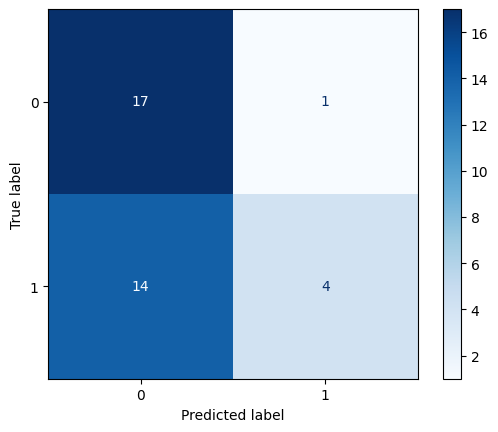

Test Accuracy: 58.33%

----- Fold 2 -----
Convert layer weights: conv1.0.weight. Shape: torch.Size([24, 1, 3, 3]) -> torch.Size([24, 1, 3, 3, 3])
Convert layer weights: conv1.3.weight. Shape: torch.Size([32, 24, 3, 3]) -> torch.Size([32, 24, 3, 3, 3])
Convert layer weights: conv1.6.weight. Shape: torch.Size([64, 32, 3, 3]) -> torch.Size([64, 32, 3, 3, 3])
Convert layer weights: layer1.0.conv1.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer1.0.conv2.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer2.0.conv1.weight. Shape: torch.Size([128, 64, 3, 3]) -> torch.Size([128, 64, 3, 3, 3])
Convert layer weights: layer2.0.conv2.weight. Shape: torch.Size([128, 128, 3, 3]) -> torch.Size([128, 128, 3, 3, 3])
Convert layer weights: layer2.0.downsample.1.weight. Shape: torch.Size([128, 64, 1, 1]) -> torch.Size([128, 64, 1, 1, 1])
Convert layer weights: layer3.0.conv1.weight. Shape: torch.Siz

accuracy,▁
train_loss,█▃▂▂▂▂▂▁▁▁▁▁
val_loss,█▁▁▁▁▁▁▁▁▁▁▁
accuracy,0.58333
train_loss,0.67612
val_loss,0.71519


Treinamento:
  Total: 64 | Homens: 32, Mulheres: 32
Validação:
  Total: 8 | Homens: 4, Mulheres: 4
Teste:
  Total: 36 | Homens: 18, Mulheres: 18
Epoch [1/1000] 		 TLoss: 0.7322 		 VLoss: 0.9566 		 TAcc: 43.75% 		 VAcc: 50.00%
Epoch [2/1000] 		 TLoss: 0.7191 		 VLoss: 0.7981 		 TAcc: 48.44% 		 VAcc: 50.00%
Epoch [3/1000] 		 TLoss: 0.7113 		 VLoss: 0.7095 		 TAcc: 43.75% 		 VAcc: 50.00%
Epoch [4/1000] 		 TLoss: 0.6948 		 VLoss: 0.6927 		 TAcc: 51.56% 		 VAcc: 50.00%
Epoch [5/1000] 		 TLoss: 0.6981 		 VLoss: 0.7030 		 TAcc: 50.00% 		 VAcc: 50.00%
Epoch [6/1000] 		 TLoss: 0.6927 		 VLoss: 0.6808 		 TAcc: 51.56% 		 VAcc: 50.00%
Epoch [7/1000] 		 TLoss: 0.6793 		 VLoss: 0.7139 		 TAcc: 64.06% 		 VAcc: 50.00%
Epoch [8/1000] 		 TLoss: 0.6896 		 VLoss: 0.6907 		 TAcc: 57.81% 		 VAcc: 50.00%
Epoch [9/1000] 		 TLoss: 0.6772 		 VLoss: 0.7238 		 TAcc: 51.56% 		 VAcc: 50.00%
Epoch [10/1000] 		 TLoss: 0.6681 		 VLoss: 0.6801 		 TAcc: 62.50% 		 VAcc: 62.50%
Epoch [11/1000] 		 TLoss: 0.6475 		 VLoss: 0

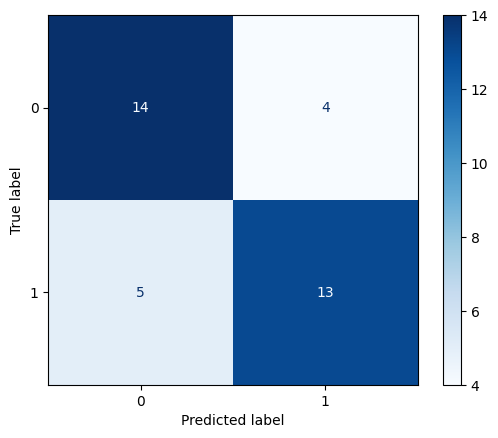

Test Accuracy: 75.00%

----- Fold 3 -----
Convert layer weights: conv1.0.weight. Shape: torch.Size([24, 1, 3, 3]) -> torch.Size([24, 1, 3, 3, 3])
Convert layer weights: conv1.3.weight. Shape: torch.Size([32, 24, 3, 3]) -> torch.Size([32, 24, 3, 3, 3])
Convert layer weights: conv1.6.weight. Shape: torch.Size([64, 32, 3, 3]) -> torch.Size([64, 32, 3, 3, 3])
Convert layer weights: layer1.0.conv1.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer1.0.conv2.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer2.0.conv1.weight. Shape: torch.Size([128, 64, 3, 3]) -> torch.Size([128, 64, 3, 3, 3])
Convert layer weights: layer2.0.conv2.weight. Shape: torch.Size([128, 128, 3, 3]) -> torch.Size([128, 128, 3, 3, 3])
Convert layer weights: layer2.0.downsample.1.weight. Shape: torch.Size([128, 64, 1, 1]) -> torch.Size([128, 64, 1, 1, 1])
Convert layer weights: layer3.0.conv1.weight. Shape: torch.Siz

accuracy,▁
train_loss,█████▇▇▇▇▇▆▆▇▅▆▅▅▅▄▄▄▄▃▄▃▃▃▃▃▂▃▃▂▂▂▂▁▃▁▁
val_loss,▆▄▄▃▄▃▄▅▃▃▃█▃▄▄▃▄▅▃▃▃▂▄▂▂▆▄▂▅▃▅▁▂▅▄▂▁▂▁▁
accuracy,0.75
train_loss,0.06647
val_loss,0.43347


Treinamento:
  Total: 64 | Homens: 32, Mulheres: 32
Validação:
  Total: 8 | Homens: 4, Mulheres: 4
Teste:
  Total: 36 | Homens: 18, Mulheres: 18
Epoch [1/1000] 		 TLoss: 0.8832 		 VLoss: 0.5758 		 TAcc: 62.50% 		 VAcc: 50.00%
Epoch [2/1000] 		 TLoss: 0.7116 		 VLoss: 0.6599 		 TAcc: 42.19% 		 VAcc: 62.50%
Epoch [3/1000] 		 TLoss: 0.7026 		 VLoss: 0.6697 		 TAcc: 50.00% 		 VAcc: 50.00%
Epoch [4/1000] 		 TLoss: 0.7022 		 VLoss: 0.6610 		 TAcc: 51.56% 		 VAcc: 62.50%
Epoch [5/1000] 		 TLoss: 0.6697 		 VLoss: 0.6420 		 TAcc: 64.06% 		 VAcc: 62.50%
Epoch [6/1000] 		 TLoss: 0.6806 		 VLoss: 0.7288 		 TAcc: 53.12% 		 VAcc: 50.00%
Epoch [7/1000] 		 TLoss: 0.6623 		 VLoss: 0.6073 		 TAcc: 56.25% 		 VAcc: 50.00%
Epoch [8/1000] 		 TLoss: 0.6362 		 VLoss: 0.3838 		 TAcc: 65.62% 		 VAcc: 75.00%
Epoch [9/1000] 		 TLoss: 0.6450 		 VLoss: 0.5018 		 TAcc: 67.19% 		 VAcc: 75.00%
Epoch [10/1000] 		 TLoss: 0.6290 		 VLoss: 0.4903 		 TAcc: 62.50% 		 VAcc: 75.00%
Epoch [11/1000] 		 TLoss: 0.6150 		 VLoss: 0

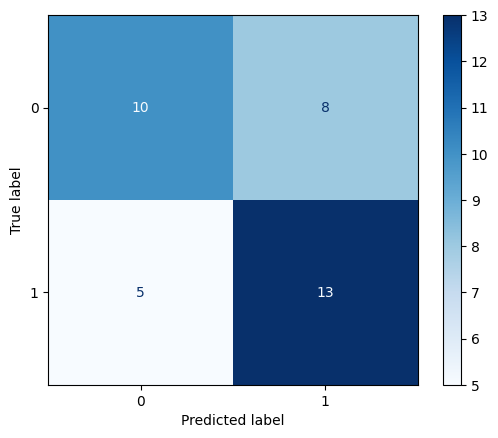

Test Accuracy: 63.89%


accuracy,▁
train_loss,█▄▄▄▃▄▃▃▃▃▂▂▂▂▅▂▂▁
val_loss,▅▇▇▇▆█▆▁▃▃▄▃▃▆▄▂▃▄
accuracy,0.63889
train_loss,0.55852
val_loss,0.51108



>>> Rodada 1 finalizada.

Tempo total de execução dos folds: 2321.33 segundos (38.69 minutos)



===== RESUMO FINAL =====
Acurácia Média: 65.74% (±6.93%)
F1-score Médio: 58.58% (±17.11%)
Precision Média: 72.79% (±7.83%)
Recall Médio: 55.56% (±23.57%)
Melhor Fold: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Resultados/Nao Binario/Resnet10/model_weights/resnet10t.c3_in1k_fold1_round0.pt com 75.00%
Pior Fold: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Resultados/Nao Binario/Resnet10/model_weights/resnet10t.c3_in1k_fold0_round0.pt com 58.33%


accuracy_best,0.75
accuracy_mean,0.65741
accuracy_std,0.06929
accuracy_worst,0.58333
best_fold,/home/labian-2/Deskt...
execution_time_minutes,38.68882
f1_score_mean,0.58578
f1_score_std,0.17111
precision_mean,0.72792
precision_std,0.07832
recall_mean,0.55556


In [35]:
all_acc = []
all_f1 = []
all_precision = []
all_recall = []
arquivos_pesos = []


skf = StratifiedKFold(n_splits=TrainingConfig.NUM_FOLDS, shuffle=True, random_state=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_weights = f"/home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Resultados/{log}/{fold_name}/model_weights/"

for round in range(1):
    print(f"\n======= Rodada {round + 1} =======")
    start_time = time.time()

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"\n----- Fold {fold + 1} -----")
        
        model, model_fc = model_configs(model_name=model_name)
        model = model.to(device)

        wandb_init(fold)
        wandb.log({"model_fc": wandb.Html(f"<pre>{str(model_fc)}</pre>")})

        model_weights_path = f'{model_weights}{model_name}_fold{fold}_round{round}.pt'
        criterion, optimizer, scheduler, es, metric = model_metrics_init(model_weights_path)

        train_loader, val_loader, test_loader = dataset_div(train_idx, test_idx)

        train_total_steps = len(train_loader)
        val_total_steps = len(val_loader)

        for epoch in range(TrainingConfig.NUM_EPOCHS):
            running_loss = 0.0
            running_acc = 0.0

            model.train()
            for images, labels, paths in train_loader:
                images, labels = images.to(device), labels.to(device).float()
                outputs = model(images)
                loss = criterion(outputs.squeeze(dim=1), labels)
                acc = metric(outputs.view(-1), labels) * 100

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                running_acc += acc.item()

            valid_loss = 0.0
            validation_acc = 0.0

            model.eval()
            with torch.no_grad():
                for images, labels, paths in val_loader:
                    images, labels = images.to(device), labels.to(device).float()
                    outputs = model(images)
                    loss = criterion(outputs.squeeze(dim=1), labels)
                    acc = metric(outputs.view(-1), labels) * 100

                    valid_loss += loss.item()
                    validation_acc += acc.item()

            avg_train_loss = running_loss / train_total_steps
            avg_valid_loss = valid_loss / val_total_steps
            avg_train_acc = running_acc / train_total_steps
            avg_valid_acc = validation_acc / val_total_steps

            wandb.log({
                "train_loss": avg_train_loss,
                "val_loss": avg_valid_loss
            }, step=epoch+1)

            scheduler.step(avg_valid_loss)

            print(f'Epoch [{epoch+1}/{TrainingConfig.NUM_EPOCHS}] \t\t '
                  f'TLoss: {avg_train_loss:.4f} \t\t '
                  f'VLoss: {avg_valid_loss:.4f} \t\t '
                  f'TAcc: {avg_train_acc:.2f}% \t\t '
                  f'VAcc: {avg_valid_acc:.2f}%')

            if es(model, avg_valid_loss):
                print(f"Early stopping ativado na época {epoch + 1}")
                break

        all_predictions = []
        all_targets = []

        model.load_state_dict(torch.load(es.save_path))
        model.eval()

        with torch.no_grad():
            print(f'========== Teste - Fold {fold} e Round {round} ==========')
            for images, labels, paths in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                probabilities = outputs  # ou torch.sigmoid(outputs) se aplicável

                predicted = torch.round(probabilities.view(-1))
                labels_flat = labels.view(-1)

                all_predictions.extend(predicted.cpu().tolist())
                all_targets.extend(labels_flat.cpu().tolist())

        # Resultados do fold
        results(all_targets, all_predictions)
        # Métricas de avaliação
        acc_value = accuracy_score(all_targets, all_predictions)
        precision = precision_score(all_targets, all_predictions, zero_division=0)
        recall = recall_score(all_targets, all_predictions, zero_division=0)
        f1 = f1_score(all_targets, all_predictions, zero_division=0)

        # Armazena métricas por fold
        all_acc.append(acc_value)
        all_precision.append(precision)
        all_recall.append(recall)
        all_f1.append(f1)
        arquivos_pesos.append(model_weights_path)

        # Loga no W&B
        wandb.log({
            "test_accuracy": acc_value,
            "test_precision": precision,
            "test_recall": recall,
            "test_f1_score": f1,
        }, step=fold)

wandb.finish()


print(f"\n>>> Rodada {round+1} finalizada.")

end_time = time.time()
elapsed_time = end_time - start_time
elapsed_minutes = elapsed_time / 60

print(f"\nTempo total de execução dos folds: {elapsed_time:.2f} segundos ({elapsed_minutes:.2f} minutos)")


# Início novo experimento para logar resumo
wandb.init(
    project=project_name, 
    name=f"Resultados do {model_name}",
    config={
        **asdict(DatasetConfig()),
        **asdict(TrainingConfig()),
        "model_name": fold_name
    }
)


# Converte para numpy
all_acc_np = np.array(all_acc)
all_f1_np = np.array(all_f1)
all_precision_np = np.array(all_precision)
all_recall_np = np.array(all_recall)

# Estatísticas
acc_mean = all_acc_np.mean()
acc_std = all_acc_np.std()
f1_mean = all_f1_np.mean()
f1_std = all_f1_np.std()
precision_mean = all_precision_np.mean()
precision_std = all_precision_np.std()
recall_mean = all_recall_np.mean()
recall_std = all_recall_np.std()

melhor = all_acc_np.max()
pior = all_acc_np.min()
melhor_fold = arquivos_pesos[np.argmax(all_acc_np)]
pior_fold = arquivos_pesos[np.argmin(all_acc_np)]

# Impressão
print("\n===== RESUMO FINAL =====")
print(f"Acurácia Média: {acc_mean * 100:.2f}% (±{acc_std * 100:.2f}%)")
print(f"F1-score Médio: {f1_mean * 100:.2f}% (±{f1_std * 100:.2f}%)")
print(f"Precision Média: {precision_mean * 100:.2f}% (±{precision_std * 100:.2f}%)")
print(f"Recall Médio: {recall_mean * 100:.2f}% (±{recall_std * 100:.2f}%)")
print(f"Melhor Fold: {melhor_fold} com {melhor * 100:.2f}%")
print(f"Pior Fold: {pior_fold} com {pior * 100:.2f}%")

# Log final no W&B
wandb.run.summary["accuracy_mean"] = acc_mean
wandb.run.summary["accuracy_std"] = acc_std
wandb.run.summary["f1_score_mean"] = f1_mean
wandb.run.summary["f1_score_std"] = f1_std
wandb.run.summary["precision_mean"] = precision_mean
wandb.run.summary["precision_std"] = precision_std
wandb.run.summary["recall_mean"] = recall_mean
wandb.run.summary["recall_std"] = recall_std
wandb.run.summary["accuracy_best"] = melhor
wandb.run.summary["accuracy_worst"] = pior
wandb.run.summary["best_fold"] = melhor_fold
wandb.run.summary["worst_fold"] = pior_fold
wandb.run.summary["execution_time_minutes"] = elapsed_minutes

wandb.finish()


#### Extração de características

##### Salvando so mapas de características

In [36]:
api = wandb.Api()
fold_name = model_map.get(model_name, "UnknownModel")

runs = api.runs(f"fernandascla-federal-university-of-cear-/{project_name}")

# Filtra os runs com nome contendo "Resultados do {model_name}"
resultados_runs = [
    run for run in runs if f"Resultados do {model_name}" in run.name
]

# Caso tenha múltiplos, selecione o mais recente (por exemplo)
resultados_runs.sort(key=lambda r: r.created_at, reverse=True)

if resultados_runs:
    run_resultado = resultados_runs[0]  # pega o mais recente
    best_fold = run_resultado.summary.get("best_fold")  # pode estar no summary
    if best_fold:
        print(f"Best fold encontrado: {best_fold}")
    else:
        print("best_fold não encontrado no run.")
else:
    print("Nenhum run com esse nome encontrado.")

Best fold encontrado: /home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Resultados/Nao Binario/Resnet10/model_weights/resnet10t.c3_in1k_fold1_round0.pt


In [44]:
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.backbone = model
        self.backbone.fc = nn.Identity()      #resnet
        #self.backbone.classifier = nn.Identity()     #densenet

    def forward(self, x):
        return self.backbone(x)

In [45]:
model_maps_path = f'/home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Resultados/{log}/{fold_name}/model_maps/model_maps.pt'

In [46]:
model_maps_path

'/home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Resultados/Nao Binario/Resnet10/model_maps/model_maps.pt'

In [47]:
features = []

model, _ = model_configs(model_name = model_name)
model.load_state_dict(torch.load(best_fold))

feature_model = FeatureExtractor(model)
feature_model = feature_model.to("cuda")

feature_model.eval()  

for i, tensor in enumerate(X):
    label = y[i]
    tensor = torch.load(tensor, weights_only=False)
    tensor = tensor.to("cuda")

    if tensor.dim() == 3:
        tensor = tensor.unsqueeze(0).unsqueeze(0) # Adiciona o batch dimension (B,C,D,H,W)

    with torch.no_grad():
        output_map = feature_model(tensor)

    features.append({
        "feature": output_map.squeeze(0).cpu(),  # Tira o batch dimension (B,C,H,W)
        "label": label
    })

torch.save(features, model_maps_path)

Convert layer weights: conv1.0.weight. Shape: torch.Size([24, 1, 3, 3]) -> torch.Size([24, 1, 3, 3, 3])
Convert layer weights: conv1.3.weight. Shape: torch.Size([32, 24, 3, 3]) -> torch.Size([32, 24, 3, 3, 3])
Convert layer weights: conv1.6.weight. Shape: torch.Size([64, 32, 3, 3]) -> torch.Size([64, 32, 3, 3, 3])
Convert layer weights: layer1.0.conv1.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer1.0.conv2.weight. Shape: torch.Size([64, 64, 3, 3]) -> torch.Size([64, 64, 3, 3, 3])
Convert layer weights: layer2.0.conv1.weight. Shape: torch.Size([128, 64, 3, 3]) -> torch.Size([128, 64, 3, 3, 3])
Convert layer weights: layer2.0.conv2.weight. Shape: torch.Size([128, 128, 3, 3]) -> torch.Size([128, 128, 3, 3, 3])
Convert layer weights: layer2.0.downsample.1.weight. Shape: torch.Size([128, 64, 1, 1]) -> torch.Size([128, 64, 1, 1, 1])
Convert layer weights: layer3.0.conv1.weight. Shape: torch.Size([256, 128, 3, 3]) -> torch.Size([256, 12

In [48]:
features

[{'feature': metatensor([0.0000e+00, 1.3728e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.9641e-01,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 4.0708e-02, 4.8905e-02, 3.7251e-02,
          0.0000e+00, 0.0000e+00, 1.8394e-02, 0.0000e+00, 8.3104e-03, 0.0000e+00,
          1.0067e-01, 1.0464e-01, 6.1485e-03, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 3.8281e-01, 0.0000e+00, 8.2711e-01, 0.0000e+00,
          0.0000e+00, 1.0495e-02, 2.0750e-02, 4.3170e-02, 4.5077e-03, 7.5083e-04,
          1.2793e+00, 5.4871e-02, 0.0000e+00, 0.0000e+00, 3.3406e-02, 3.5340e-02,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 9.6090e-03,
          2.0606e-02, 0.0000e+00, 0.0000e+00, 7.2600e-03, 0.0000e+00, 4.8328e-02,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0666e-02, 0.0000e+00, 9.7210e-05,
          4.5162e-04, 6.8318e-02, 0.0000e+00, 4.9521e-01, 0.0000e+00, 0.0000e+00,
          0.0000e+00, 0.0000e+00, 0.0000e+00, 4.1826e-01, 0.0000e+00, 0.0000e+00,
 

## Algoritmos

#### Bibliotecas

In [42]:
import os

import torch
from torch import Tensor
import torch.nn.functional as F
from typing import Tuple
from torchmetrics.classification import BinaryAccuracy
import time 

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,accuracy_score, precision_score, f1_score, recall_score, matthews_corrcoef

import matplotlib.pyplot as plt

import numpy as np

from dataclasses import dataclass

import pandas as pd
import matplotlib.pyplot as plt
from torch.autograd import Variable
import wandb
import copy
from dataclasses import asdict

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import timm_3d

#Modelos
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

### Carregamento dos tensores

In [49]:
# Extrai os tensores de features (cada um com shape [2048])
feature_tensors = [item["feature"] for item in features]
labels_tensors = [item["label"] for item in features]

# Empilha no eixo 0 → resultado tem shape [n_amostras, 2048]
features_tensor = torch.stack(feature_tensors)
labels_tensor = torch.tensor(labels_tensors)

print(features_tensor.shape)  # Exemplo: [100, 2048]
print(labels_tensor.shape)    # Exemplo: [100]

torch.Size([108, 512])
torch.Size([108])


In [50]:
features_tensor = torch.stack(feature_tensors)
labels_tensor = torch.tensor(labels_tensors)

# Converte de tensor para numpy - Serão meus dados
X = features_tensor.numpy()
y = labels_tensor.numpy()

print(fold_name)
print(X.shape, y.shape) 

Resnet10
(108, 512) (108,)


Arquivos de métricas

In [51]:
def writeMetricFiles(file_name, metrics, best_metrics, final_metrics, stds, times, n=TrainingConfig.NUM_FOLDS):
    with open(file_name, 'w') as f:
        f.write('Final Metrics:\n')
        f.write(f'Acc: {final_metrics[0]*100:.2f}%\n')
        f.write(f'Std Acc: {stds[0]*100:.2f}%\n')
        f.write(f'F1_score: {final_metrics[1]*100:.2f}%\n')
        f.write(f'Std F1_score: {stds[1]*100:.2f}%\n')
        f.write(f'Recall: {final_metrics[2]*100:.2f}%\n')
        f.write(f'Std Recall: {stds[2]*100:.2f}%\n')
        f.write(f'Precision: {final_metrics[3]*100:.2f}%\n')
        f.write(f'Std Precision: {stds[3]*100:.2f}%\n')

        f.write('--------------------- Best Results ---------------------\n')
        f.write(f'Acc: {best_metrics[0]*100:.2f}%\n')
        f.write(f'F1_score: {best_metrics[1]*100:.2f}%\n')
        f.write(f'Recall: {best_metrics[2]*100:.2f}%\n')
        f.write(f'Precision: {best_metrics[3]*100:.2f}%\n')
        f.write(f'Best Matrix:\n{best_metrics[4]}\n')

        f.write('--------------------- 5 iterations ---------------------\n')
        f.write(f'Acc: {metrics[0]}\n')
        f.write(f'F1_score: {metrics[1]}\n')
        f.write(f'Recall: {metrics[2]}\n')
        f.write(f'Precision: {metrics[3]}\n')
        f.write(f'Matrices: {metrics[4]}\n')

        f.write('--------------------- Times ---------------------\n')
        f.write(f'Train Time: {sum(times[0])/n:.4f}s\n')
        f.write(f'Test Time: {sum(times[1])/n:.4f}s\n')
    print('Arquivo gravado...')

Classificadores

In [52]:
def SVM_classifier(X, y, skf):
    conf_mat = np.zeros((2, 2))
    acc, prec, f1s, rec = [], [], [], []
    conf_matrixs = []

    acc_best = prec_best = f1_best = rec_best = -99
    matrix_best = None

    train_time, test_time = [], []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f'------------------------------- Rodada {fold} -------------------------------')

        X_train_raw, X_test_raw = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train, X_test = X_train_raw, X_test_raw

        print("Sizes:")
        print(f"X_train:{X_train.shape}\ty_train:{y_train.shape}")
        print(f"X_test:{X_test.shape}\ty_test:{y_test.shape}")

        print('Treinando....')
        svm_model = SVC(kernel='rbf')

        train_begin = time.time()
        svm_model.fit(X_train, y_train)
        train_time.append(time.time() - train_begin)

        print('========================================')
        print('Testando....')
        test_begin = time.time()
        y_pred = svm_model.predict(X_test)
        test_time.append(time.time() - test_begin)

        test_acc = accuracy_score(y_test, y_pred)
        print(f'{fold} Acurácia do teste: {test_acc}')

        cm = confusion_matrix(y_test, y_pred)
        conf_mat += cm
        print('------- Matriz de confusão --------')
        print(cm)

        # Métricas com average (ajuste se for multiclasse)
        acc.append(test_acc)
        prec.append(precision_score(y_test, y_pred, average='binary'))
        f1s.append(f1_score(y_test, y_pred, average='binary'))
        rec.append(recall_score(y_test, y_pred, average='binary'))
        conf_matrixs.append(cm)

        if test_acc > acc_best:
            acc_best = test_acc
            prec_best = precision_score(y_test, y_pred, average='binary')
            f1_best = f1_score(y_test, y_pred, average='binary')
            rec_best = recall_score(y_test, y_pred, average='binary')
            matrix_best = cm

        print('========================================\n')

    # Finais
    Kfold = len(acc)
    stds = [np.std(acc), np.std(f1s), np.std(rec), np.std(prec)]
    final_metrics = [np.mean(acc), np.mean(f1s), np.mean(rec), np.mean(prec), conf_mat]
    best_metrics = [acc_best, f1_best, rec_best, prec_best, matrix_best]
    metrics = [acc, f1s, rec, prec, conf_matrixs]
    times = [train_time, test_time]

    return metrics, best_metrics, final_metrics, stds, times


In [53]:
def KNN_classifier(X, y,skf):
    conf_mat = np.zeros((2,2))
    acc = []
    prec = []
    f1s = []
    rec = []
    conf_matrixs = []

    acc_best = -99
    prec_best = -99
    f1_best = -99
    rec_best = -99
    matrix_best = -99

    train_time = []
    test_time = []

    test_total_size = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f'------------------------------- Rodada {fold} -------------------------------')
        
        X_train_raw, X_test_raw = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train, X_test = X_train_raw, X_test_raw

        print("Sizes:")
        print(f"X_train:{X_train.shape}\ty_train:{y_train.shape}")
        print(f"X_test:{X_test.shape}\ty_test:{y_test.shape}")

        print('Treinando....', end='\n')

        knn_model = KNeighborsClassifier(n_neighbors=5)

        train_begin = time.time()
        knn_model.fit(X_train, y_train)
        train_end = time.time()

        train_time.append((train_end - train_begin))

        print('========================================')
        print('Testando....', end='\n')

        test_begin = time.time()
        y_pred = knn_model.predict(X_test)
        test_end = time.time()

        test_time.append((test_end - test_begin))

        test_acc = accuracy_score(y_test, y_pred)
        print(f'{fold} Acurácia do teste: {test_acc}')

        cm = confusion_matrix(y_test, y_pred)
        conf_mat += cm

        print('------- Matriz de confusão --------')
        print(cm, end='\n')

        # Métricas com average (ajuste se for multiclasse)
        acc.append(test_acc)
        prec.append(precision_score(y_test, y_pred, average='binary'))
        f1s.append(f1_score(y_test, y_pred, average='binary'))
        rec.append(recall_score(y_test, y_pred, average='binary'))
        conf_matrixs.append(cm)

        if test_acc > acc_best:
            acc_best = test_acc
            prec_best = precision_score(y_test, y_pred, average='binary')
            f1_best = f1_score(y_test, y_pred, average='binary')
            rec_best = recall_score(y_test, y_pred, average='binary')
            matrix_best = cm

        print('========================================\n')

    # Finais
    Kfold = len(acc)
    stds = [np.std(acc), np.std(f1s), np.std(rec), np.std(prec)]
    final_metrics = [np.mean(acc), np.mean(f1s), np.mean(rec), np.mean(prec), conf_mat]
    best_metrics = [acc_best, f1_best, rec_best, prec_best, matrix_best]
    metrics = [acc, f1s, rec, prec, conf_matrixs]
    times = [train_time, test_time]

    return metrics, best_metrics, final_metrics, stds, times


In [54]:
def MLP_classifier(X, y,skf):
    conf_mat = np.zeros((2,2))
    acc = []
    prec = []
    f1s = []
    rec = []
    conf_matrixs = []

    acc_best = -99
    prec_best = -99
    f1_best = -99
    rec_best = -99
    matrix_best = -99

    train_time = []
    test_time = []

    test_total_size = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f'------------------------------- Rodada {fold} -------------------------------')
        
        X_train_raw, X_test_raw = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]


        X_train, X_test = X_train_raw, X_test_raw

        print("Sizes:")
        print(f"X_train:{X_train.shape}\ty_train:{y_train.shape}")
        print(f"X_test:{X_test.shape}\ty_test:{y_test.shape}")

        print('Treinando....', end='\n')

        mlp_model = MLPClassifier(random_state=1, max_iter = 300)

        train_begin = time.time()
        mlp_model.fit(X_train, y_train)
        train_end = time.time()

        train_time.append((train_end - train_begin))

        print('========================================')
        print('Testando....', end='\n')

        test_begin = time.time()
        y_pred = mlp_model.predict(X_test)
        test_end = time.time()

        test_time.append((test_end - test_begin))

        test_acc = accuracy_score(y_test, y_pred)
        print(f'{fold} Acurácia do teste: {test_acc}')

        cm = confusion_matrix(y_test, y_pred)
        conf_mat += cm

        print('------- Matriz de confusão --------')
        print(cm, end='\n')

        #Calcula as métricas da iteração
        acc.append(accuracy_score(y_test, y_pred))
        prec.append(precision_score(y_test, y_pred,average='binary'))
        f1s.append(f1_score(y_test, y_pred,average='binary'))
        rec.append(recall_score(y_test, y_pred,average='binary'))

        conf_matrixs.append(cm)

        if test_acc > acc_best:
            acc_best = test_acc
            prec_best = precision_score(y_test, y_pred, average='binary')
            f1_best = f1_score(y_test, y_pred, average='binary')
            rec_best = recall_score(y_test, y_pred, average='binary')
            matrix_best = cm

        print('========================================\n')

    # Finais
    Kfold = len(acc)
    stds = [np.std(acc), np.std(f1s), np.std(rec), np.std(prec)]
    final_metrics = [np.mean(acc), np.mean(f1s), np.mean(rec), np.mean(prec), conf_mat]
    best_metrics = [acc_best, f1_best, rec_best, prec_best, matrix_best]
    metrics = [acc, f1s, rec, prec, conf_matrixs]
    times = [train_time, test_time]

    return metrics, best_metrics, final_metrics, stds, times


In [55]:
def RF_classifier(X, y,skf, use_pca=False):
    conf_mat = np.zeros((2, 2))
    acc = []
    prec = []
    f1s = []
    rec = []
    conf_matrixs = []

    acc_best = -99
    prec_best = -99
    f1_best = -99
    rec_best = -99
    matrix_best = -99

    train_time = []
    test_time = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f'------------------------------- Rodada {fold} -------------------------------')
        X_train_raw, X_test_raw = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train, X_test = X_train_raw, X_test_raw

        print("Sizes:")
        print(f"X_train:{X_train.shape}\ty_train:{y_train.shape}")
        print(f"X_test:{X_test.shape}\ty_test:{y_test.shape}")

        print('Treinando....', end='\n')
        rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

        train_begin = time.time()
        rf_model.fit(X_train, y_train)
        train_end = time.time()
        train_time.append((train_end - train_begin))

        print('========================================')
        print('Testando....', end='\n')
        test_begin = time.time()
        y_pred = rf_model.predict(X_test)
        test_end = time.time()
        test_time.append((test_end - test_begin))

        test_acc = accuracy_score(y_test, y_pred)
        print(f'{fold} Acurácia do teste: {test_acc}')

        cm = confusion_matrix(y_test, y_pred)
        conf_mat += cm
        print('------- Matriz de confusão --------')
        print(cm)

        # Métricas
        acc.append(test_acc)
        prec.append(precision_score(y_test, y_pred, average='binary'))
        f1s.append(f1_score(y_test, y_pred, average='binary'))
        rec.append(recall_score(y_test, y_pred, average='binary'))

        conf_matrixs.append(cm)

        if test_acc > acc_best:
            acc_best = test_acc
            prec_best = precision_score(y_test, y_pred, average='binary')
            f1_best = f1_score(y_test, y_pred, average='binary')
            rec_best = recall_score(y_test, y_pred, average='binary')
            matrix_best = cm

        print('========================================\n')

    # Finais
    Kfold = len(acc)
    stds = [np.std(acc), np.std(f1s), np.std(rec), np.std(prec)]
    final_metrics = [np.mean(acc), np.mean(f1s), np.mean(rec), np.mean(prec), conf_mat]
    best_metrics = [acc_best, f1_best, rec_best, prec_best, matrix_best]
    metrics = [acc, f1s, rec, prec, conf_matrixs]
    times = [train_time, test_time]

    return metrics, best_metrics, final_metrics, stds, times


Resultados

In [56]:
path_metrics=f'/home/labian-2/Desktop/Crateus/odonto_forense/Resultados e Tensores/Resultados/{log}/{fold_name}/results/'

In [57]:
cnn_file_name = 'metricas_svm_' + fold_name + '.txt'  # nome do arquivo para salvar as métricas

# Chamada da função para treinar e avaliar o classificador MLP com k-fold
metrics, best_metrics, final_metrics, stds, times = SVM_classifier(X, y,skf)

# Grava as métricas no arquivo de texto
writeMetricFiles(path_metrics + cnn_file_name, metrics, best_metrics, final_metrics, stds, times)

------------------------------- Rodada 0 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
0 Acurácia do teste: 0.8888888888888888
------- Matriz de confusão --------
[[15  3]
 [ 1 17]]

------------------------------- Rodada 1 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
1 Acurácia do teste: 0.7222222222222222
------- Matriz de confusão --------
[[13  5]
 [ 5 13]]

------------------------------- Rodada 2 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
2 Acurácia do teste: 0.9722222222222222
------- Matriz de confusão --------
[[17  1]
 [ 0 18]]

Arquivo gravado...


In [58]:
cnn_file_name = 'metricas_mlp_' + fold_name + '.txt'  # nome do arquivo para salvar as métricas

# Chamada da função para treinar e avaliar o classificador MLP com k-fold
metrics, best_metrics, final_metrics, stds, times = MLP_classifier(X, y,skf)

# Grava as métricas no arquivo de texto
writeMetricFiles(path_metrics + cnn_file_name, metrics, best_metrics, final_metrics, stds, times)

------------------------------- Rodada 0 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
0 Acurácia do teste: 0.8888888888888888
------- Matriz de confusão --------
[[16  2]
 [ 2 16]]

------------------------------- Rodada 1 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
1 Acurácia do teste: 0.7222222222222222
------- Matriz de confusão --------
[[15  3]
 [ 7 11]]

------------------------------- Rodada 2 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
2 Acurácia do teste: 1.0
------- Matriz de confusão --------
[[18  0]
 [ 0 18]]

Arquivo gravado...


In [59]:
cnn_file_name = 'metricas_rf_' + fold_name + '.txt'  # nome do arquivo para salvar as métricas

# Chamada da função para treinar e avaliar o classificador MLP com k-fold
metrics, best_metrics, final_metrics, stds, times = RF_classifier(X, y,skf)

# Grava as métricas no arquivo de texto
writeMetricFiles(path_metrics + cnn_file_name, metrics, best_metrics, final_metrics, stds, times)

------------------------------- Rodada 0 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
0 Acurácia do teste: 0.9444444444444444
------- Matriz de confusão --------
[[17  1]
 [ 1 17]]

------------------------------- Rodada 1 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
1 Acurácia do teste: 0.7222222222222222
------- Matriz de confusão --------
[[15  3]
 [ 7 11]]

------------------------------- Rodada 2 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
2 Acurácia do teste: 1.0
------- Matriz de confusão --------
[[18  0]
 [ 0 18]]

Arquivo gravado...


In [60]:
cnn_file_name = 'metricas_knn_' + fold_name + '.txt'  # nome do arquivo para salvar as métricas

# Chamada da função para treinar e avaliar o classificador MLP com k-fold
metrics, best_metrics, final_metrics, stds, times = KNN_classifier(X, y,skf)

# Grava as métricas no arquivo de texto
writeMetricFiles(path_metrics + cnn_file_name, metrics, best_metrics, final_metrics, stds, times)

------------------------------- Rodada 0 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
0 Acurácia do teste: 0.8888888888888888
------- Matriz de confusão --------
[[15  3]
 [ 1 17]]

------------------------------- Rodada 1 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
1 Acurácia do teste: 0.75
------- Matriz de confusão --------
[[14  4]
 [ 5 13]]

------------------------------- Rodada 2 -------------------------------
Sizes:
X_train:(72, 512)	y_train:(72,)
X_test:(36, 512)	y_test:(36,)
Treinando....
Testando....
2 Acurácia do teste: 0.9722222222222222
------- Matriz de confusão --------
[[17  1]
 [ 0 18]]

Arquivo gravado...
